In [1]:
from matplotlib import colors
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import seaborn as sns
import math
import matplotlib.cm as cm
from scipy.signal import savgol_filter
import json

distance_parsecs = 5400
Mag_min = -50  # 0
Mag_max = 50   # 35
RMS_max = 1     # 0.1 #No quiero que aparezcan varias estrellas dentro del circulo, pues si eso sucede de todas formas no será posible dar un valor correcto
Fit_max = 1.5   # También puede ser 0.6, pero en en los filtros 606 y 814 no se pueden usar valores tan estrictos, pues se eliminarían demasiados puntos
Sharp_min = -2  # -0.25
Sharp_max = 2   # 0.25
bins_division = 20


NGC = "NGC6809"
gráfico_comp = 1
min_count = 2
min_step = 2
CM_min = 80

bluer_limit = 0.5
significantly_bluer_limit = 1.0
redder_limit = 0.5
significantly_redder_limit = 1.0


path_optical = 'C:/Users/HP/Desktop/Curso de Python/Workspace/miweb/Astronomía/NGC 6809/NGC6809.txt'
optical_data = pd.read_csv(
    path_optical,
    sep=r"\s+",      # split by any amount of whitespace
    header=None      # because there are no column names
)
optical_data.columns = [
        "X", "Y",
        "275_Mag", "275_RMS", "275_Fit", "275_Sharp", "275_exp_found", "275_exp_well",
        "336_Mag", "336_RMS", "336_Fit", "336_Sharp", "336_exp_found", "336_exp_well",
        "438_Mag", "438_RMS", "438_Fit", "438_Sharp", "438_exp_found", "438_exp_well",
        "606_Mag", "606_RMS", "606_Fit", "606_Sharp", "606_exp_found", "606_exp_well",
        "814_Mag", "814_RMS", "814_Fit", "814_Sharp", "814_exp_found", "814_exp_well",
        "Cluster_Membership",
        "RA", "Decl",
        "Id",
        "Iteration_found"
]


optical_data["Visible"] = (optical_data["438_Mag"]+optical_data["606_Mag"])/2

optical_data["Mv"] = optical_data["Visible"]-5*(math.log(distance_parsecs/10,10))

bands = ["275", "336", "438", "606", "814"]
mask = np.ones(len(optical_data), dtype=bool)
for b in bands:
    mask &= optical_data[f"{b}_Mag"].between(Mag_min, Mag_max)
    mask &= optical_data[f"{b}_RMS"] < RMS_max
    mask &= optical_data[f"{b}_Fit"] < Fit_max
    mask &= optical_data[f"{b}_Sharp"].between(Sharp_min, Sharp_max)
    mask &= optical_data["Cluster_Membership"] > CM_min


optical_data_filtered = optical_data[mask].copy()
optical_data_filtered.reset_index(inplace = True)
column_drop = ["X", "Y", "Iteration_found", "index"]
for i in bands:
    column_drop.append(i+"_RMS")
    column_drop.append(i+"_Fit")
    column_drop.append(i+"_Sharp")
    column_drop.append(i+"_exp_found")
    column_drop.append(i+"_exp_well")
optical_data_filtered.drop(columns = column_drop, inplace = True)

NGC = "NGC6809"
gráfico_comp = 0
min_count = 2
min_step = 2
optical_data_filtered.sort_index(inplace = True)
optical_data_filtered['275 - 336'] = optical_data_filtered["275_Mag"] - optical_data_filtered["336_Mag"]
optical_data_filtered['438 - 606'] = optical_data_filtered["438_Mag"] - optical_data_filtered["606_Mag"]
optical_data_filtered['606 - 814'] = optical_data_filtered["606_Mag"] - optical_data_filtered["814_Mag"]
optical_data_filtered

,275_Mag,336_Mag,438_Mag,606_Mag,814_Mag,Cluster_Membership,RA,Decl,Id,Visible,Mv,275 - 336,438 - 606,606 - 814
0,18.4874,17.7728,18.0470,17.2860,16.6878,95.0,294.996186,-30.992472,R0000045,17.66650,4.004531,0.7146,0.7610,0.5982
1,18.2868,17.2289,17.2647,16.2836,15.5637,97.7,294.995930,-30.992443,R0000046,16.77415,3.112181,1.0579,0.9811,0.7199
2,18.6973,18.0672,18.3685,17.6917,17.1151,97.6,294.996051,-30.992217,R0000052,18.03010,4.368131,0.6301,0.6768,0.5766
3,18.5293,17.8373,18.0689,17.4010,16.7947,96.8,294.994840,-30.992029,R0000056,17.73495,4.072981,0.6920,0.6679,0.6063
4,19.5017,18.8582,19.2310,18.4397,17.8733,97.8,294.996446,-30.991643,R0000063,18.83535,5.173381,0.6435,0.7913,0.5664
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11585,23.0362,21.5343,21.5414,20.4450,19.6733,96.5,294.991260,-30.936518,R0045252,20.99320,7.331231,1.5019,1.0964,0.7717
11586,19.7004,19.0157,19.4706,18.6382,18.0522,97.7,294.997340,-30.935677,R0045267,19.05440,5.392431,0.6847,0.8324,0.5860
11587,25.0711,22.7921,22.4562,20.9407,20.1081,95.8,294.996743,-30.936112,R0045268,21.69845,8.036481,2.2790,1.5155,0.8326
11588,20.7275,19.9519,20.1673,19.3836,18.7379,95.2,294.992073,-30.935783,R0045299,19.77545,6.113481,0.7756,0.7837,0.6457


In [2]:
gráfico_comp = 0
#for gráfico_comp in range(3):
if gráfico_comp == 0: #F275W-F336W
    Color1 = "275"
    Color2 = "336"
elif gráfico_comp == 1: #F438W-F606W
    Color1 = "438"
    Color2 = "606"
elif gráfico_comp == 2: #F606W-F814W
    Color1 = "606"
    Color2 = "814"
optical_data_filtered[f"{Color1} - {Color2}"] = optical_data_filtered[f"{Color1}_Mag"] - optical_data_filtered[f"{Color2}_Mag"]
S_Color1 = optical_data_filtered[Color1+"_Mag"]
S_Color2 = optical_data_filtered[Color2+"_Mag"]
S_dif = optical_data_filtered[f"{Color1} - {Color2}"]
n_Data = len(S_Color1)

xmax = round(S_dif.max()+1)
xmin = round(S_dif.min()-1)
ymax = round(S_Color2.max()+1)
ymin = round(S_Color2.min()-1)

bins_xy = [bins_division*(xmax-xmin), bins_division*(ymax-ymin)]
range_xy = [[xmin, xmax], [ymin, ymax]]

H, x_edges, y_edges = np.histogram2d(S_dif, S_Color2, bins = bins_xy, range = range_xy)

for i in range(len(H)):
    for j in range(len(H[0])):
        if H[i][j] < min_count:
            H[i][j] = 0

x = []
min = []
max = []
for i in H.T:
    #First we go for every bin to find the position of the bins with stars, and we save the count of consecutive 
    # bins with stars (ou) and the count of consecutive bins without stars (n).
    l = []
    k = []
    ll = []
    kk = []
    ku = []
    kkuu = []
    ou = 0
    o = 0
    oo = 0
    n = 0
    c = 0
    for j,z in enumerate(i):
        #We consider that a bin has stars if its count is greater than 0, and we save the position and count of the 
        # bins with stars in k and kk, and we save the position and count of the last consecutive bins with stars in 
        # ku and kkuu.
        if z > 0:
            n = 0
            c = 0
            o += 1
            k.append(j)     #position
            kk.append(z)    #value
            ku = []
            kkuu = []
            ou = 0
        else:
            n += 1
            c += 2
            if n < 2:
                ku = k
                kkuu = kk
                ou = o
                o += 1
                k.append(j)     #position
                kk.append(z)    #value
            else:
                if ou > oo and ou >= min_step:
                    ll = kkuu
                    l = ku
                    oo = ou
                kk = []
                k = []
                o = 0
                ku = []
                kkuu = []
                ou = 0
    #We save the position of the left and right limits of the main sequence. If there are no stars in any bin, 
    # we save 0 as the limits.
    if len(l)>0:
        min.append(l[0])
        max.append(l[-1])
    else:
        min.append(0)
        max.append(0)
    total = 0
    #We also save the mean position of the bins with stars to plot the mean line of the main sequence.
    if len(l) > 0:
        for j in range(len(l)):
            total += l[j]*ll[j]
        x.append(total/sum(ll))
    else:
        x.append(0)


container = []
chain_width = 0
maximum = 0
for i,j in enumerate(x):
    if j == 0:
        container.append(i)
for i in range(len(container)-1):
    m = container[i+1]-container[i]-1
    if m > maximum:
        maximum = m
        chain_width = container[i]
main_sequence = range(chain_width+1,chain_width+maximum)
#Extract the positions (in cells) of the mean, max and min of the main sequence to plot them later. 
filtered_x = [x[i] for i in main_sequence]
filtered_max = [max[i] for i in main_sequence]
filtered_min = [min[i] for i in main_sequence]
#We obtain the position of the start of the main sequence turn off.
derivative_x = []
for i in range(len(x)-1):
    derivative_x.append(x[i]-x[i+1])
container_d = []
chain_width_d = 0
maximum_d = 0
for i,j in enumerate(derivative_x):
    if j <= 0:
        container_d.append(i)
for i in range(len(container_d)-1):
    m_d = container_d[i+1]-container_d[i]-1
    if m_d > maximum_d:
        maximum_d = m_d
        chain_width_d = container_d[i]
msto_start = chain_width_d+maximum_d
#Change the positions from cells to magnitude values of the CMD
normalized_min = (np.array(filtered_min)/bins_division)+xmin+1/(2*bins_division)
normalized_max = (np.array(filtered_max)/bins_division)+xmin-1/(2*bins_division)
#Smooth the lines of the minimum and maximum of the main sequence using the Savitzky-Golay filter.
window_size = 11
poly_order = 3
min_smooth = savgol_filter(normalized_min, window_size, poly_order)
max_smooth = savgol_filter(normalized_max, window_size, poly_order)
main_sequence_y_magnitude = np.array(main_sequence)/bins_division+ymin+1/(2*bins_division)
msto_start_y_magnitude = msto_start/bins_division+ymin+1/(2*bins_division)

In [3]:
optical_data_filtered[f"position_{gráfico_comp}"] = ""

for i in range(len(main_sequence_y_magnitude)-1):
    xmin_1 = min_smooth[i]
    xmin_2 = min_smooth[i+1]
    xmax_1 = max_smooth[i]
    xmax_2 = max_smooth[i+1]
    y_1 = main_sequence_y_magnitude[i]
    y_2 = main_sequence_y_magnitude[i+1]
    slope = (xmin_2-xmin_1)/(y_2-y_1)
    for j in optical_data_filtered.index:
        y = optical_data_filtered.loc[j, Color2+"_Mag"]
        if y >= main_sequence_y_magnitude[0] and y < main_sequence_y_magnitude[-1]:
            if y >= y_1 and y < y_2:
                x = optical_data_filtered.loc[j, f"{Color1} - {Color2}"]
                x_min_real =  xmin_1+(y-y_1)*slope
                x_max_real =  xmax_1+(y-y_1)*slope
                if i <= msto_start_index-1:
                    if x < x_min_real - significantly_bluer_limit:
                        optical_data_filtered.loc[j, f"position_{gráfico_comp}"] = "bluer than MS L3"
                    elif x < x_min_real - bluer_limit:
                        optical_data_filtered.loc[j, f"position_{gráfico_comp}"] = "bluer than MS L2"
                    elif x < x_min_real:
                        optical_data_filtered.loc[j, f"position_{gráfico_comp}"] = "bluer than MS L1"
                    elif x < x_max_real:
                        optical_data_filtered.loc[j, f"position_{gráfico_comp}"] = "MSTO"
                    elif x < x_max_real + redder_limit:
                        optical_data_filtered.loc[j, f"position_{gráfico_comp}"] = "sub-sub-giant branch"
                    elif x < x_max_real + significantly_redder_limit:
                        optical_data_filtered.loc[j, f"position_{gráfico_comp}"] = "redder than MS L2"
                    else:
                        optical_data_filtered.loc[j, f"position_{gráfico_comp}"] = "redder than MS L3"
                else:
                    if x < x_min_real - significantly_bluer_limit:
                        optical_data_filtered.loc[j, f"position_{gráfico_comp}"] = "bluer than MS L3"
                    elif x < x_min_real - bluer_limit:
                        optical_data_filtered.loc[j, f"position_{gráfico_comp}"] = "bluer than MS L2"
                    elif x < x_min_real:
                        optical_data_filtered.loc[j, f"position_{gráfico_comp}"] = "bluer than MS L1"
                    elif x < x_max_real:
                        optical_data_filtered.loc[j, f"position_{gráfico_comp}"] = "MS"
                    elif x < x_max_real + redder_limit:
                        optical_data_filtered.loc[j, f"position_{gráfico_comp}"] = "redder than MS L1"
                    elif x < x_max_real + significantly_redder_limit:
                        optical_data_filtered.loc[j, f"position_{gráfico_comp}"] = "redder than MS L2"
                    else:
                        optical_data_filtered.loc[j, f"position_{gráfico_comp}"] = "redder than MS L3"


NameError: name 'msto_start_index' is not defined

In [ ]:
optical_data_filtered__MS

In [102]:
#point_A
x_A = min_smooth[np.where(msto_start_y_magnitude == main_sequence_y_magnitude)[0][0]]
y_A = msto_start_y_magnitude
#point_B
x_B = min_smooth[0]
y_B = main_sequence_y_magnitude[0]
Min_MS = main_sequence_y_magnitude[-1]

slope_m = (x_B - x_A)/(y_B - y_A)

#We use this variables to write less code
x = f"{Color1} - {Color2}"
y = Color2+"_Mag"
odf = optical_data_filtered

In [98]:
region1 = odf[odf[y] >= Min_MS]
region2 = odf[(odf[y] < Min_MS) & (odf[y] >= y_A)]
region3 = odf[((odf[y] < y_A) & (odf[y] >= y_B) & (odf[x] > x_A+slope_m * (odf[y]-y_A)))
               | ((odf[x] > x_B) & (odf[y] < y_B))]
region4 = odf[((odf[y] < y_A) & (odf[y] >= y_B) & (odf[x] <= x_A+slope_m * (odf[y]-y_A)))
               | ((odf[x] <= x_B) & (odf[y] < y_B))]
#S_Color2 = optical_data_filtered[Color2+"_Mag"]
#    S_dif = optical_data_filtered[f"{Color1} - {Color2}"]

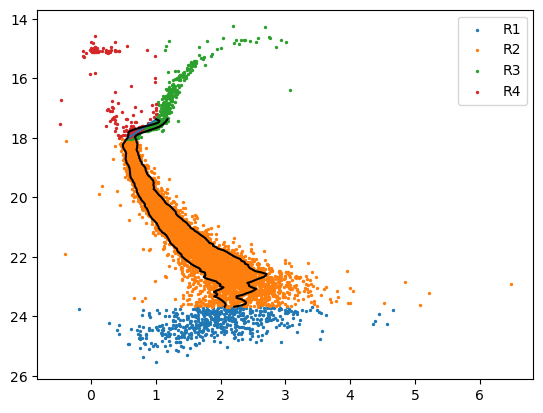

In [76]:
plt.scatter(region1[x], region1[y], s=2, label='R1')
plt.scatter(region2[x], region2[y], s=2, label='R2')
plt.scatter(region3[x], region3[y], s=2, label='R3')
plt.scatter(region4[x], region4[y], s=2, label='R4')
plt.plot([x_A, x_B], [y_A, y_B])
plt.plot(min_smooth, main_sequence_y_magnitude, c = "black")
plt.plot(max_smooth, main_sequence_y_magnitude, c = "black")

plt.gca().invert_yaxis()
plt.legend()
plt.show()

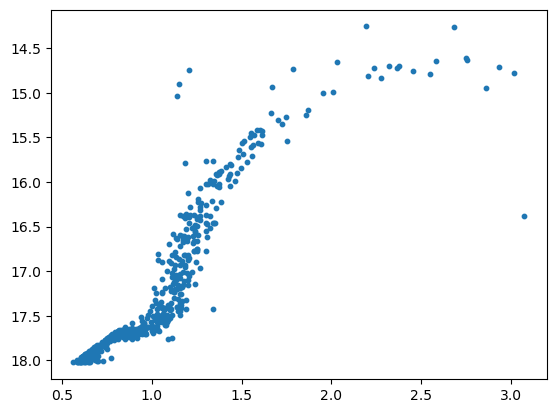

In [86]:
plt.scatter(region3[x], region3[y], s = 10)
plt.gca().invert_yaxis()
plt.show()

In [4]:
    main_sequence_y_magnitude_over = []
    main_sequence_y_magnitude_under = []
    max_smooth_over = []
    max_smooth_under = []
    min_smooth_over = []
    min_smooth_under = []
    msto = []
    for i in range(len(main_sequence_y_magnitude)):
        if main_sequence_y_magnitude[i] <= msto_start_y_magnitude:
            main_sequence_y_magnitude_under.append(main_sequence_y_magnitude[i])
            max_smooth_under.append(max_smooth[i])
            min_smooth_under.append(min_smooth[i])
            msto.append(i)
            
        else:
            main_sequence_y_magnitude_over.append(main_sequence_y_magnitude[i])
            max_smooth_over.append(max_smooth[i])
            min_smooth_over.append(min_smooth[i])

    msto_start_index = np.array(msto).max()
    main_sequence_y_magnitude_over = np.array(main_sequence_y_magnitude_over)
    main_sequence_y_magnitude_under = np.array(main_sequence_y_magnitude_under)
    max_smooth_over = np.array(max_smooth_over)
    max_smooth_under = np.array(max_smooth_under)
    min_smooth_over = np.array(min_smooth_over)
    min_smooth_under = np.array(min_smooth_under)

    optical_data_filtered[f"position_{gráfico_comp}"] = ""

    mask1 = optical_data_filtered[f"{Color2}_Mag"] < main_sequence_y_magnitude.min()
    mask2 = optical_data_filtered[f"{Color2}_Mag"] > main_sequence_y_magnitude.max()
    mask3 = (main_sequence_y_magnitude.min() <= optical_data_filtered[f"{Color2}_Mag"]) & (optical_data_filtered[f"{Color2}_Mag"] <= main_sequence_y_magnitude.max())

    optical_data_filtered_above_MS = optical_data_filtered[mask1].copy()
    optical_data_filtered_below_MS = optical_data_filtered[mask2].copy()
    optical_data_filtered__MS = optical_data_filtered[mask3].copy()




    for i in range(len(main_sequence_y_magnitude)-1):
        xmin_1 = min_smooth[i]
        xmin_2 = min_smooth[i+1]
        xmax_1 = max_smooth[i]
        xmax_2 = max_smooth[i+1]
        y_1 = main_sequence_y_magnitude[i]
        y_2 = main_sequence_y_magnitude[i+1]
        slope = (xmin_2-xmin_1)/(y_2-y_1)
        for j in optical_data_filtered__MS.index:
            y = optical_data_filtered__MS.loc[j, Color2+"_Mag"]
            if y >= y_1 and y < y_2:
                x = optical_data_filtered__MS.loc[j, f"{Color1} - {Color2}"]
                x_min_real =  xmin_1+(y-y_1)*slope
                x_max_real =  xmax_1+(y-y_1)*slope
                if i <= msto_start_index-1:
                    if x < x_min_real - significantly_bluer_limit:
                        optical_data_filtered__MS.loc[j, f"position_{gráfico_comp}"] = "bluer than MS L3"
                    elif x < x_min_real - bluer_limit:
                        optical_data_filtered__MS.loc[j, f"position_{gráfico_comp}"] = "bluer than MS L2"
                    elif x < x_min_real:
                        optical_data_filtered__MS.loc[j, f"position_{gráfico_comp}"] = "bluer than MS L1"
                    elif x < x_max_real:
                        optical_data_filtered__MS.loc[j, f"position_{gráfico_comp}"] = "MSTO"
                    elif x < x_max_real + redder_limit:
                        optical_data_filtered__MS.loc[j, f"position_{gráfico_comp}"] = "sub-sub-giant branch"
                    elif x < x_max_real + significantly_redder_limit:
                        optical_data_filtered__MS.loc[j, f"position_{gráfico_comp}"] = "redder than MS L2"
                    else:
                        optical_data_filtered__MS.loc[j, f"position_{gráfico_comp}"] = "redder than MS L3"
                else:
                    if x < x_min_real - significantly_bluer_limit:
                        optical_data_filtered__MS.loc[j, f"position_{gráfico_comp}"] = "bluer than MS L3"
                    elif x < x_min_real - bluer_limit:
                        optical_data_filtered__MS.loc[j, f"position_{gráfico_comp}"] = "bluer than MS L2"
                    elif x < x_min_real:
                        optical_data_filtered__MS.loc[j, f"position_{gráfico_comp}"] = "bluer than MS L1"
                    elif x < x_max_real:
                        optical_data_filtered__MS.loc[j, f"position_{gráfico_comp}"] = "MS"
                    elif x < x_max_real + redder_limit:
                        optical_data_filtered__MS.loc[j, f"position_{gráfico_comp}"] = "redder than MS L1"
                    elif x < x_max_real + significantly_redder_limit:
                        optical_data_filtered__MS.loc[j, f"position_{gráfico_comp}"] = "redder than MS L2"
                    else:
                        optical_data_filtered__MS.loc[j, f"position_{gráfico_comp}"] = "redder than MS L3"



In [5]:
optical_data_filtered_below_MS[f"position_{gráfico_comp}"] = "below the MS"
optical_data_filtered_below_MS

,275_Mag,336_Mag,438_Mag,606_Mag,814_Mag,Cluster_Membership,RA,Decl,Id,Visible,Mv,275 - 336,position_0
2344,26.7678,24.0461,23.1216,21.5654,20.6200,97.0,294.993899,-30.991482,R0004410,22.34350,8.681531,2.7217,below the MS
2345,25.9755,25.0872,23.9411,22.0986,20.9449,94.8,294.993544,-30.990502,R0004413,23.01985,9.357881,0.8883,below the MS
2354,25.4751,23.6798,22.8861,21.4963,20.5632,95.6,295.001090,-30.991504,R0004466,22.19120,8.529231,1.7953,below the MS
2363,26.5946,24.3688,23.6444,21.8104,20.8158,92.7,294.996883,-30.991311,R0004500,22.72740,9.065431,2.2258,below the MS
2378,25.4031,24.0551,23.2138,21.6383,20.6794,97.7,295.006475,-30.989586,R0004929,22.42605,8.764081,1.3480,below the MS
...,...,...,...,...,...,...,...,...,...,...,...,...,...
11528,25.3659,24.3219,23.1513,21.7713,20.7614,94.3,295.001853,-30.937273,R0044539,22.46130,8.799331,1.0440,below the MS
11535,25.9013,23.7424,23.2659,21.6214,20.6349,96.3,294.989776,-30.937186,R0044578,22.44365,8.781681,2.1589,below the MS
11553,26.0069,24.2283,24.0552,22.0706,21.0221,95.6,294.991832,-30.937280,R0044638,23.06290,9.400931,1.7786,below the MS
11555,25.7329,24.0772,23.2559,21.6911,20.7430,97.6,294.995652,-30.937496,R0044662,22.47350,8.811531,1.6557,below the MS


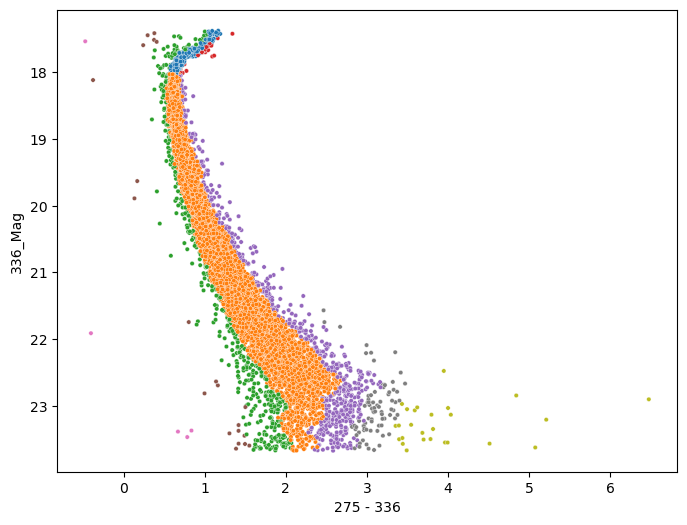

In [6]:
#plt.scatter(optical_data_filtered__MS["275 - 336"], optical_data_filtered__MS["336_Mag"], c = optical_data_filtered__MS[f"position_{gráfico_comp}"], s = 0.1, colormap = 'viridis')
#plt.fill_betweenx(main_sequence_y_magnitude_under, min_smooth_under, max_smooth_under, color = "yellow", alpha = 0.25)
#plt.fill_betweenx(main_sequence_y_magnitude_over, min_smooth_over, max_smooth_over, color = "cyan", alpha = 0.25)
#plt.fill_betweenx(main_sequence_y_magnitude_under, max_smooth_under, max_smooth_under+0.5, color = "green", alpha = 0.25)
#plt.fill_betweenx(main_sequence_y_magnitude_over, max_smooth_over, max_smooth_over+0.5, color = "#F5836C", alpha = 0.25)
#plt.fill_betweenx(main_sequence_y_magnitude, max_smooth+0.5, max_smooth+1, color = "#F75B3B", alpha = 0.25)
#plt.fill_betweenx(main_sequence_y_magnitude, max_smooth+1, xmax, color = "#FF2B00", alpha = 0.25)
#plt.fill_betweenx(main_sequence_y_magnitude, min_smooth, min_smooth-0.5, color = "#9386FC", alpha = 0.25)
#plt.fill_betweenx(main_sequence_y_magnitude, min_smooth-0.5, min_smooth-1, color = "#5842FF", alpha = 0.25)
#plt.fill_betweenx(main_sequence_y_magnitude, min_smooth-1, xmin, color = "#1E00FF", alpha = 0.25)
#plt.fill_betweenx([ymax, main_sequence_y_magnitude.max()], [xmin, xmin], [xmax, xmax], color = "purple", alpha = 0.25)
#plt.fill_betweenx([ymin, main_sequence_y_magnitude.min()], [xmin, xmin], [xmax, xmax], color = "brown", alpha = 0.25)
plt.figure(figsize=(8, 6)) # Optional: adjust figure size
sns.scatterplot(data=optical_data_filtered__MS, x=f"{Color1} - {Color2}", y=f"{Color2}_Mag", hue=f"position_{gráfico_comp}", s = 10, legend = False)
plt.gca().invert_yaxis()
plt.show()

In [7]:
optical_data_filtered_below_MS[f"position_{gráfico_comp}"] = "Not defined"
optical_data_filtered_below_MS

,275_Mag,336_Mag,438_Mag,606_Mag,814_Mag,Cluster_Membership,RA,Decl,Id,Visible,Mv,275 - 336,position_0
2344,26.7678,24.0461,23.1216,21.5654,20.6200,97.0,294.993899,-30.991482,R0004410,22.34350,8.681531,2.7217,Not defined
2345,25.9755,25.0872,23.9411,22.0986,20.9449,94.8,294.993544,-30.990502,R0004413,23.01985,9.357881,0.8883,Not defined
2354,25.4751,23.6798,22.8861,21.4963,20.5632,95.6,295.001090,-30.991504,R0004466,22.19120,8.529231,1.7953,Not defined
2363,26.5946,24.3688,23.6444,21.8104,20.8158,92.7,294.996883,-30.991311,R0004500,22.72740,9.065431,2.2258,Not defined
2378,25.4031,24.0551,23.2138,21.6383,20.6794,97.7,295.006475,-30.989586,R0004929,22.42605,8.764081,1.3480,Not defined
...,...,...,...,...,...,...,...,...,...,...,...,...,...
11528,25.3659,24.3219,23.1513,21.7713,20.7614,94.3,295.001853,-30.937273,R0044539,22.46130,8.799331,1.0440,Not defined
11535,25.9013,23.7424,23.2659,21.6214,20.6349,96.3,294.989776,-30.937186,R0044578,22.44365,8.781681,2.1589,Not defined
11553,26.0069,24.2283,24.0552,22.0706,21.0221,95.6,294.991832,-30.937280,R0044638,23.06290,9.400931,1.7786,Not defined
11555,25.7329,24.0772,23.2559,21.6911,20.7430,97.6,294.995652,-30.937496,R0044662,22.47350,8.811531,1.6557,Not defined


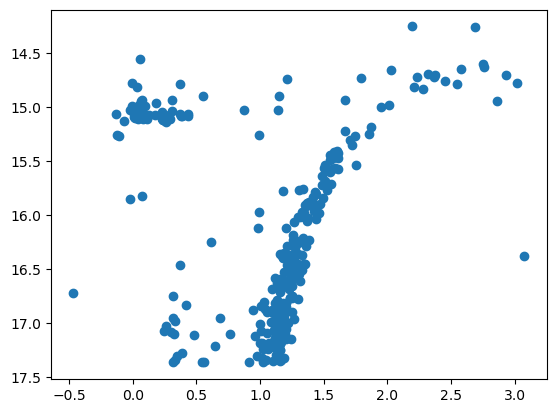

In [8]:
x = optical_data_filtered_above_MS[f"{Color1} - {Color2}"]
y = optical_data_filtered_above_MS[f"{Color2}_Mag"]
plt.scatter(x,y)
plt.gca().invert_yaxis()
plt.show()

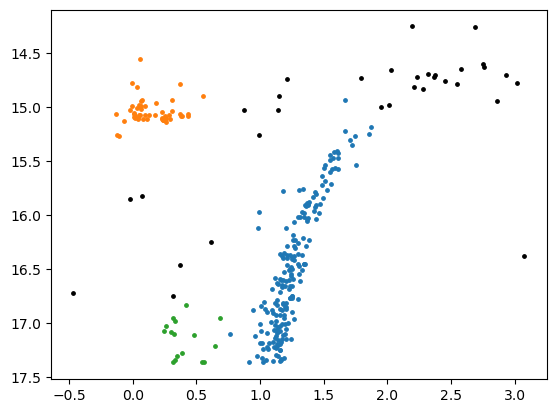

In [9]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
import numpy as np
import matplotlib.pyplot as plt

x = optical_data_filtered_above_MS[f"{Color1} - {Color2}"]
y = optical_data_filtered_above_MS[f"{Color2}_Mag"]

X = np.column_stack((x, y))

# Normalize
X_scaled = StandardScaler().fit_transform(X)

db = DBSCAN(eps=0.4, min_samples=15).fit(X_scaled)
labels = db.labels_

unique_labels = set(labels)

plt.figure()

for label in unique_labels:

    if label == -1:
        color = "black"
        size = 6
    else:
        color = plt.cm.tab10(label)
        size = 6

    mask = labels == label

    plt.scatter(x[mask], y[mask], c=[color], s=size)

plt.gca().invert_yaxis()
plt.show()

In [10]:
labels

array([ 0,  1, -1,  0,  0,  0,  0,  1,  0,  1,  0,  0,  1, -1,  0,  0,  0,
        0,  0, -1,  1,  0,  1,  0,  0,  0,  0,  0,  1,  0,  0,  0,  0,  0,
        0,  0,  1,  0, -1,  0,  0,  0,  0,  0,  0,  0,  1,  0,  0,  0,  0,
        1,  1,  0,  0,  0,  0,  2,  1, -1,  0,  2,  0,  0,  0,  0, -1,  0,
        1,  0,  0, -1, -1,  0,  0,  2,  0,  0, -1,  0,  1, -1, -1,  0, -1,
        0,  0,  1,  0,  0,  2,  0,  0,  0,  0,  0,  0,  1,  2,  1,  0,  0,
        0,  0,  1,  0,  0,  0, -1,  0, -1,  0,  1,  0,  0,  0,  1,  0,  0,
        0, -1,  0,  0,  0,  0,  0,  0,  2,  0,  0,  0,  0,  1,  0,  2,  0,
        0,  0,  0,  0,  0,  0,  0,  0, -1,  0,  1,  1,  1,  1,  1, -1,  0,
        0,  0,  0,  2,  0,  0, -1,  0,  1,  1,  0,  0,  0,  2,  0,  0,  0,
        1,  0,  0,  0,  0,  0,  1,  0, -1,  1,  0,  2,  1,  0,  0, -1,  0,
        0,  1,  0,  0,  2, -1,  0,  2,  0,  0,  0,  1,  2,  0,  0,  1,  0,
       -1,  0, -1,  0,  0, -1,  1,  0,  0,  0,  1,  0,  0,  0,  0,  0,  1,
       -1,  0,  0,  0, -1

In [11]:
optical_data_filtered_above_MS[f"position_{gráfico_comp}"] = labels
optical_data_filtered_above_MS

,275_Mag,336_Mag,438_Mag,606_Mag,814_Mag,Cluster_Membership,RA,Decl,Id,Visible,Mv,275 - 336,position_0
1,18.2868,17.2289,17.2647,16.2836,15.5637,97.7,294.995930,-30.992443,R0000046,16.77415,3.112181,1.0579,0
8,15.1973,15.1169,15.1068,15.0104,14.8765,95.9,295.000249,-30.991080,R0000082,15.05860,1.396631,0.0804,1
9,17.0916,14.7252,13.8983,12.3706,11.4002,93.2,294.999198,-30.990933,R0000087,13.13445,-0.527519,2.3664,-1
10,17.3016,15.9752,15.6505,14.5769,13.7817,96.4,294.991564,-30.990415,R0000100,15.11370,1.451731,1.3264,0
11,17.2835,15.9104,15.6878,14.5891,13.7923,97.9,295.002037,-30.990358,R0000103,15.13845,1.476481,1.3731,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2316,15.2753,15.0487,14.7401,14.5943,14.3864,92.8,294.987121,-30.939403,R0003233,14.66720,1.005231,0.2266,1
2327,17.9797,16.8830,16.8759,15.9132,15.1717,97.4,294.996888,-30.937885,R0003283,16.39455,2.732581,1.0967,0
2329,18.0080,16.7554,16.8496,15.7700,15.0558,97.3,294.999991,-30.937754,R0003288,16.30980,2.647831,1.2526,0
2333,16.9662,15.9748,15.7879,14.0878,13.3005,98.0,295.002170,-30.937145,R0003309,14.93785,1.275881,0.9914,0


In [12]:
counts = optical_data_filtered_above_MS[f"position_{gráfico_comp}"].value_counts()
counts_sorted = counts.drop(-1).sort_values(ascending = False)

label_map = {
    counts_sorted.index[0]: "Red giant branch",
    counts_sorted.index[1]: "Blue straggler",
}

optical_data_filtered_above_MS[f"position_{gráfico_comp}"] = (
    optical_data_filtered_above_MS[f"position_{gráfico_comp}"].map(label_map)
)
optical_data_filtered_above_MS.fillna("Not defined", inplace = True)

In [13]:
df_merged = pd.concat([optical_data_filtered__MS, optical_data_filtered_below_MS, optical_data_filtered_above_MS]).sort_index()
df_merged.loc[9]

275_Mag                   17.0916
336_Mag                   14.7252
438_Mag                   13.8983
606_Mag                   12.3706
814_Mag                   11.4002
Cluster_Membership           93.2
RA                     294.999198
Decl                   -30.990933
Id                       R0000087
Visible                  13.13445
Mv                      -0.527519
275 - 336                  2.3664
position_0            Not defined
Name: 9, dtype: object

In [14]:
#optical_data_filtered = df_merged.join(df_merged[["275 - 336",f"position_{gráfico_comp}"]])

optical_data_filtered[[f"position_{gráfico_comp}"]] = df_merged[[f"position_{gráfico_comp}"]]

In [15]:
optical_data_filtered.head(10)

,275_Mag,336_Mag,438_Mag,606_Mag,814_Mag,Cluster_Membership,RA,Decl,Id,Visible,Mv,275 - 336,position_0
0,18.4874,17.7728,18.0470,17.2860,16.6878,95.0,294.996186,-30.992472,R0000045,17.66650,4.004531,0.7146,MSTO
1,18.2868,17.2289,17.2647,16.2836,15.5637,97.7,294.995930,-30.992443,R0000046,16.77415,3.112181,1.0579,Red giant branch
2,18.6973,18.0672,18.3685,17.6917,17.1151,97.6,294.996051,-30.992217,R0000052,18.03010,4.368131,0.6301,MS
3,18.5293,17.8373,18.0689,17.4010,16.7947,96.8,294.994840,-30.992029,R0000056,17.73495,4.072981,0.6920,MSTO
4,19.5017,18.8582,19.2310,18.4397,17.8733,97.8,294.996446,-30.991643,R0000063,18.83535,5.173381,0.6435,MS
5,19.0616,18.5276,18.8959,18.1255,17.5573,97.4,294.997720,-30.991603,R0000065,18.51070,4.848731,0.5340,bluer than MS L1
6,19.1429,18.5058,18.8209,18.1356,17.5772,97.4,294.997743,-30.991483,R0000069,18.47825,4.816281,0.6371,MS
7,19.0430,18.4163,18.7644,18.0650,17.5030,96.2,294.997170,-30.991136,R0000079,18.41470,4.752731,0.6267,MS
8,15.1973,15.1169,15.1068,15.0104,14.8765,95.9,295.000249,-30.991080,R0000082,15.05860,1.396631,0.0804,Blue straggler
9,17.0916,14.7252,13.8983,12.3706,11.4002,93.2,294.999198,-30.990933,R0000087,13.13445,-0.527519,2.3664,Not defined


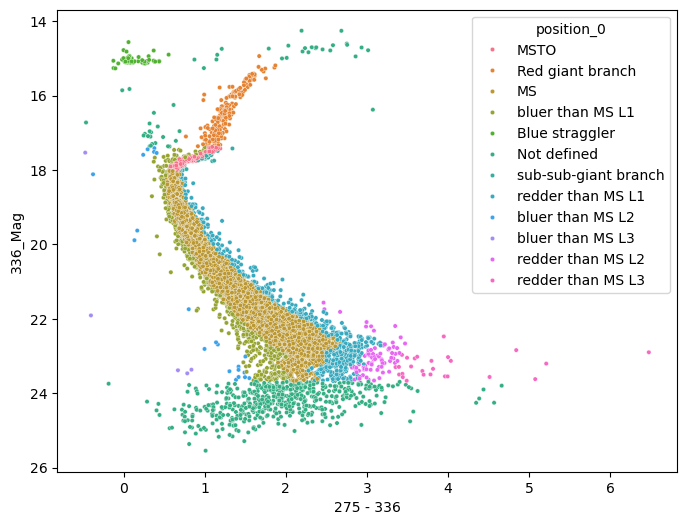

In [16]:
plt.figure(figsize=(8, 6)) # Optional: adjust figure size
sns.scatterplot(data=optical_data_filtered, x=f"{Color1} - {Color2}", y=f"{Color2}_Mag", hue=f"position_{gráfico_comp}", s = 10)
plt.gca().invert_yaxis()
plt.show()

In [17]:
optical_data_filtered["position_0"].value_counts()

position_0
MS                      9044
redder than MS L1        593
Not defined              582
MSTO                     519
bluer than MS L1         440
Red giant branch         198
redder than MS L2         80
Blue straggler            53
sub-sub-giant branch      29
redder than MS L3         26
bluer than MS L2          21
bluer than MS L3           5
Name: count, dtype: int64